In [3]:
import math
import matplotlib.pyplot as plt

In [4]:
def read_csv(csv_file):
    with open(csv_file, 'r') as f:
        lines = f.readlines()
        data = []
        for line in lines[1:]:
            row = line.strip().split(',')
            data.append(row)
    return data

data = read_csv('data/loan2.csv')
print(data)

x1 = [[float(row[0])] for row in data]
x2 = [[float(row[1])] for row in data]
y = [[float(row[2])] for row in data]   
print(f'Experience: {x1}')
print(f'Salary: {x2}')
print(f'y: {y}')

print(f"Shape of Experience: ({len(x1)}, {len(x1[0])})")
print(f"Shape of Salary: ({len(x2)}, {len(x2[0])})")
print(f"Shape of y: ({len(y)}, {len(y[0])})")

[['3', '4', '1'], ['2.5', '4', '1'], ['1', '4', '0'], ['2.5', '5', '1'], ['2', '5', '1'], ['1.5', '5', '0'], ['0.5', '5', '0'], ['1.75', '6', '1'], ['0.25', '6', '0'], ['1', '7', '1'], ['0.25', '7', '0'], ['0.20', '7', '0'], ['0.15', '7', '0'], ['2', '8', '1'], ['1', '8', '0'], ['0.15', '8', '0'], ['0.10', '8', '0'], ['0.5', '9', '1'], ['1', '10', '1']]
Experience: [[3.0], [2.5], [1.0], [2.5], [2.0], [1.5], [0.5], [1.75], [0.25], [1.0], [0.25], [0.2], [0.15], [2.0], [1.0], [0.15], [0.1], [0.5], [1.0]]
Salary: [[4.0], [4.0], [4.0], [5.0], [5.0], [5.0], [5.0], [6.0], [6.0], [7.0], [7.0], [7.0], [7.0], [8.0], [8.0], [8.0], [8.0], [9.0], [10.0]]
y: [[1.0], [1.0], [0.0], [1.0], [1.0], [0.0], [0.0], [1.0], [0.0], [1.0], [0.0], [0.0], [0.0], [1.0], [0.0], [0.0], [0.0], [1.0], [1.0]]
Shape of Experience: (19, 1)
Shape of Salary: (19, 1)
Shape of y: (19, 1)


In [5]:
def sigmoid(z):
    return 1.0 / (1 + math.exp(-z))

def loss_function(N, x1, x2, y, w): # Cross entropy
    total_loss = 0
    for i in range(N):
        y_hat = w[0] + w[1] * x1[i][0] + w[2] * x2[i][0]
        yi = y[i][0]
        total_loss += yi * y_hat - math.log(1 + math.exp(y_hat))
    return - total_loss / N

def gradient(N, x1, x2, y, w):
    grad = [0.0, 0.0, 0.0]
    for i in range(N):
        x1_i = x1[i][0]
        x2_i = x2[i][0]
        yi = y[i][0]
        y_hat = w[0] + w[1] * x1_i + w[2] * x2_i
        grad[0] += 1 - yi - sigmoid(-y_hat)
        grad[1] += -yi*x1_i + x1_i * (1 - sigmoid(-y_hat))
        grad[2] += -yi*x2_i + x2_i * (1 - sigmoid(-y_hat))

    grad[0] = grad[0] / N
    grad[1] = grad[1] / N
    grad[2] = grad[2] / N
    return grad

def gradient_descent(x1, x2, y, lr, threshold=1e-6):
    N = len(y)
    w = [0.0, 1.0, 2.0]
    count = 0
    converged = False
    loss = float('inf')

    while not converged:
        grad = gradient(N, x1, x2, y, w)
        w[0] -= lr*grad[0]
        w[1] -= lr*grad[1]
        w[2] -= lr*grad[2]
        new_loss = loss_function(N, x1, x2, y, w)
        count += 1
        if count % 100 == 0:
            print(f"Iteration {count}: Loss={new_loss:.3f}")

        if abs(new_loss - loss) < threshold:
            converged = True
            print(f"Model converged after {count} iterations")
        loss = new_loss

    print('Final weights:')
    print(f'w0 = {w[0]:.3f}, w1 = {w[1]:.3f}, w2 = {w[2]:.3f}')
    return w

In [15]:
def plot_logistic_regression(x1, x2, y, w):
    for i in range(len(y)):
        color = 'blue' if y[i][0] else 'red'
        plt.scatter(x1[i][0], x2[i][0], c=color)
    
    x1_min, x1_max = min(x1)[0], max(x1)[0]
    x2_start = -(w[1] * x1_min + w[0]) / w[2]
    x2_end = -(w[1] * x1_max + w[0]) / w[2]

    plt.plot([x1_min, x1_max], [x2_start, x2_end], color='green', label='Boundary')
    x2_min, x2_max = min(x2)[0], max(x2)[0]
    plt.ylim(x2_min - 1, x2_max + 1)
    plt.xlabel('Experience')
    plt.ylabel('Salary')
    plt.show()


Iteration 100: Loss=5.905
Iteration 200: Loss=4.701
Iteration 300: Loss=3.498
Iteration 400: Loss=2.311
Iteration 500: Loss=1.240
Iteration 600: Loss=0.649
Iteration 700: Loss=0.525
Iteration 800: Loss=0.508
Iteration 900: Loss=0.504
Iteration 1000: Loss=0.503
Iteration 1100: Loss=0.501
Iteration 1200: Loss=0.500
Iteration 1300: Loss=0.499
Iteration 1400: Loss=0.498
Iteration 1500: Loss=0.497
Iteration 1600: Loss=0.495
Iteration 1700: Loss=0.494
Iteration 1800: Loss=0.493
Iteration 1900: Loss=0.492
Iteration 2000: Loss=0.491
Iteration 2100: Loss=0.490
Iteration 2200: Loss=0.489
Iteration 2300: Loss=0.488
Iteration 2400: Loss=0.487
Iteration 2500: Loss=0.487
Iteration 2600: Loss=0.486
Iteration 2700: Loss=0.485
Iteration 2800: Loss=0.484
Iteration 2900: Loss=0.483
Iteration 3000: Loss=0.482
Iteration 3100: Loss=0.482
Iteration 3200: Loss=0.481
Iteration 3300: Loss=0.480
Iteration 3400: Loss=0.479
Iteration 3500: Loss=0.479
Iteration 3600: Loss=0.478
Iteration 3700: Loss=0.477
Iteration 

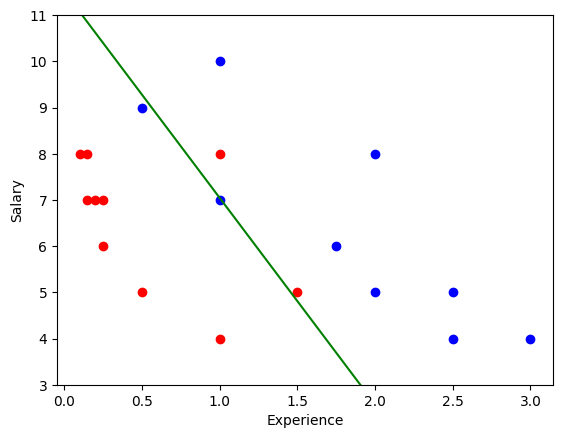

In [16]:
learning_rate = 0.001
threshold = 1e-7
w = gradient_descent(x1, x2, y, lr=learning_rate, threshold=threshold)
plot_logistic_regression(x1, x2, y, w)